In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2015_TTlowP_t0.06.fits")
lth = arange(len(clth[0]))
clth[:,:2] = np.nan

## Models

### Planck

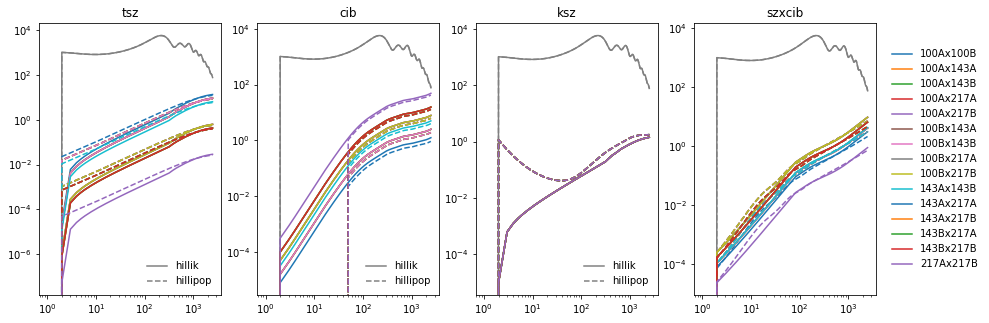

In [2]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

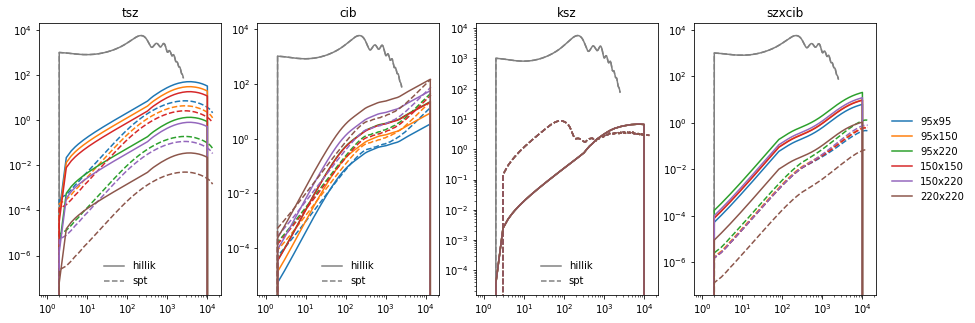

In [3]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

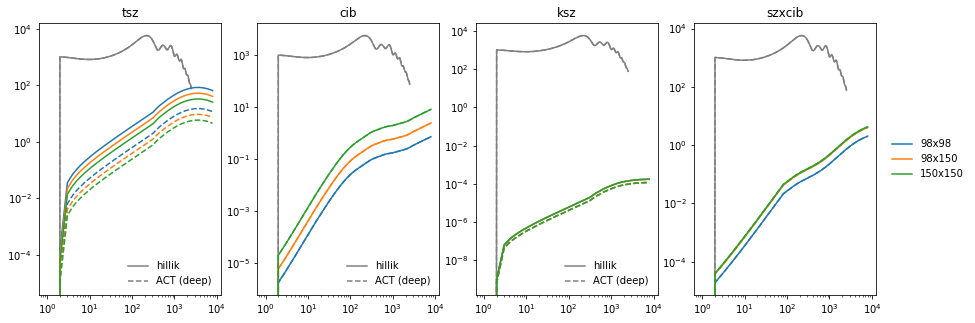

In [4]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

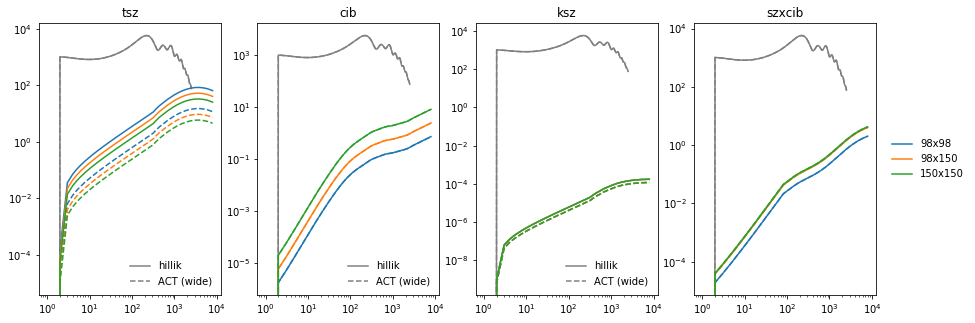

In [5]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

# Variance

In [2]:
PKdir = "/sps/planck/Users/tristram/Soft/Hillik/modules/data"
tags = {'TT':0,'EE':1,'BB':2,'TE':3}
np.seterr('ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
#PLK
PLK = {}
for it,tag in enumerate(['TT','TE','EE']):
    binning = fits.getdata( f"{PKdir}/planck_2020/hillipop/data/binning_ext.fits",tags[tag]+1)[[0,1,3,9,10,14]]
    vPLK = np.diag(fits.getdata( f"{PKdir}/planck_2020/hillipop/data/fll_NPIPE_detset_ext_{tag}.fits"))*1e24
    PLK[tag] = np.zeros( (len(binning), max(binning['LMAX'])+1) )*np.inf
    t0 = 0
    for t in range(len(binning)):
        l = arange( binning[t][0], binning[t][1]+1)
        PLK[tag][t][array(l,int)] = vPLK[t0:t0+len(l)]
        t0 += len(l)
    PLK[tag][~isfinite(PLK[tag])] = np.inf

In [4]:
#ACTpol
ACTtag = {'TT':[0,1,2], 'TE':[3,4,5,6], 'EE':[7,8,9]}
nbin,nspec = 52,10
l = arange(7924)
wACTw = loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_bpwf_100mJy_191127_lmin2.txt")
vACTw = diag(loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_cov_100mJy_200519.txt"))
ACTw = {k:np.ones( (len(v),7924) ) for k,v in ACTtag.items()}
for isp in range(nspec):
    bwf = wACTw[isp*nbin:(isp+1)*nbin]
    w8 = np.zeros((nbin,len(l)))
    for b in range(nbin): w8[b,bwf[b]>5e-4] = mean(bwf[b,bwf[b] > 0.8*max(bwf[b])])
    for tag,itag in ACTtag.items():
        if isp in itag: ACTw[tag][itag.index(isp)] = 1./diag(w8.T@w8)*(w8.T@vACTw[isp*nbin:(isp+1)*nbin])
for tag in ['TT','TE','EE']: ACTw[tag][~isfinite(ACTw[tag])] = np.inf

wACTd = loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_bpwf_15mJy_191127_lmin2.txt")
vACTd = diag(loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_cov_15mJy_200519.txt"))
ACTd = {k:np.ones( (len(v),7924) ) for k,v in ACTtag.items()}
for isp in range(nspec):
    bwf = wACTd[isp*nbin:(isp+1)*nbin]
    w8 = np.zeros((nbin,len(l)))
    for b in range(nbin): w8[b,bwf[b]>5e-4] = mean(bwf[b,bwf[b] > 0.8*max(bwf[b])])
    for tag,itag in ACTtag.items():
        if isp in itag: ACTd[tag][itag.index(isp)] = 1./diag(w8.T@w8)*(w8.T@vACTd[isp*nbin:(isp+1)*nbin])

for tag in ['TT','TE','EE']: ACTd[tag][~isfinite(ACTd[tag])] = np.inf

In [5]:
#SPT
SPT = {}
import struct
filename = f"{PKdir}/spt_hiell_2020/likelihood/data/spt_hiell_2020/spt_hiell_2020_window.bin"
with open(filename, "rb") as f:
    efflmin, efflmax = struct.unpack("@II", f.read(2 * np.dtype(np.int32).itemsize))
offset = 2 * (np.dtype(np.int32).itemsize)
wSPT = np.fromfile(filename, dtype=np.float64, offset=offset).reshape(88, -1)
vSPT = diag(fromfile( f"{PKdir}/spt_hiell_2020/likelihood/data/spt_hiell_2020/spt_hiell_2020_cov.bin", dtype=np.float64).reshape(88,88))
xname = {"95x95":13,"95x150":15,"95x220":15,"150x150":15,"150x220":15,"220x200":15}
l = arange(13491)
SPT['TT']= np.ones( (len(xname),13491) )*np.inf
nbins = array( [v for v in xname.values()])
for i,nb in enumerate(nbins):
    bmin,bmax = sum(nbins[:i]),sum(nbins[:i+1])
    bwf = wSPT[bmin:bmax]
    w8 = np.zeros((nb,len(l)))
    for b in range(nb): w8[b,bwf[b]>5e-4] = mean(bwf[b,bwf[b] > 0.8*max(bwf[b])])
    SPT['TT'][i] = 1./diag(w8.T@w8)*(w8.T@vSPT[bmin:bmax])

#SPT 3G
filename = f"{PKdir}/spt3g_2018/SPT3G_2018_EETE_likelihood_v3/data/SPT3G_Y1_EETE/windows/window"
nbins,nspec,lmax=44,12,3200
wSPT = np.zeros( (nbins, nspec, lmax+1) )
for ib in range(nbins):
    wSPT[ib,:,1:] = np.loadtxt( filename+"_%d.txt" % (ib+1)).T[1:]
vSPT = diag(loadtxt( f"{PKdir}/spt3g_2018/SPT3G_2018_EETE_likelihood_v3/data/SPT3G_Y1_EETE/SPT3G_Y1_EETE_covariance.dat"))
# EE 90x90 TE 90x90 EE 90x150 TE 90x150 EE 90x220 TE 90x220 EE 150x150 TE 150x150 EE 150x220 TE 150x220 EE 220x220 TE 220x220
SPT['EE'] = np.ones( (nspec//2,lmax+1) )*np.inf
SPT['TE'] = np.ones( (nspec//2,lmax+1) )*np.inf
for i in range(nspec):
    bwf = wSPT[:,i,:]
    w8 = np.zeros((nbins,lmax+1))
    for b in range(nbins): w8[b,bwf[b]>0.005] = mean(bwf[b,bwf[b] > 0.8*max(bwf[b])])
    if i%2 == 0: SPT['EE'][i//2] = 1./diag(w8.T@w8)*(w8.T@vSPT[i*nbins:(i+1)*nbins])
    if i%2 == 1: SPT['TE'][i//2] = 1./diag(w8.T@w8)*(w8.T@vSPT[i*nbins:(i+1)*nbins])

for tag in ['TT','TE','EE']: SPT[tag][~isfinite(SPT[tag])] = np.inf

(1.0, 10000.0)

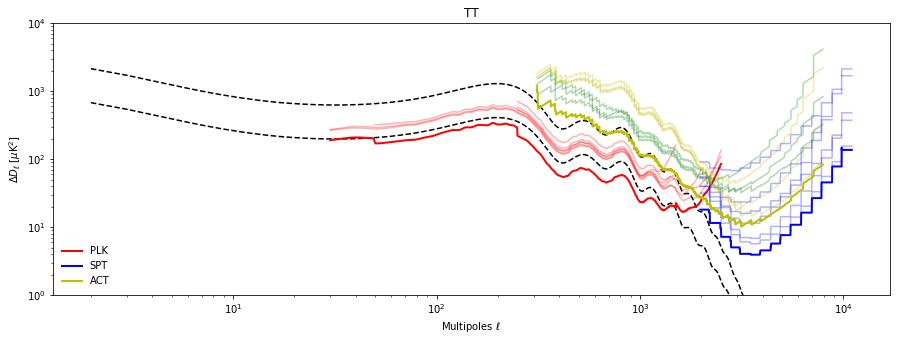

In [11]:
#TT
figure(figsize=(15,5))
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[0]**2+clth[0]**2)/(2*lth+1))*1e12, 'k--')
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[0]**2+clth[0]**2)/(2*lth+1)/0.1)*1e12, 'k--')
l = arange( 2501)
plot( l, sqrt(PLK['TT'].T), 'r', alpha=0.3)
plot( l, 1/sqrt(sum(1./PLK['TT'],0)), 'r', lw=2, label="PLK")
l = arange( 13491)
plot( l, sqrt(SPT['TT'].T), 'b', alpha=0.3)
plot( l, 1/sqrt(sum(1./SPT['TT'],0)), 'b', lw=2, label="SPT")
l = arange( 7924)
plot( l, (l*(l+1)/2/pi*sqrt(ACTw['TT'])).T, 'g', alpha=0.3)
plot( l, (l*(l+1)/2/pi*sqrt(ACTd['TT'])).T, 'y', alpha=0.3)
plot( l, l*(l+1)/2/pi/sqrt(sum(1./ACTw['TT']+1./ACTd['TT'],0)), 'y', lw=2, label="ACT")
loglog()
legend()
title("TT")
xlabel( "Multipoles $\ell$")
ylabel( "$\Delta D_\ell$ [$\mu$K$^2$]")
ylim( 1e0, 1e4)

(0.5, 5000.0)

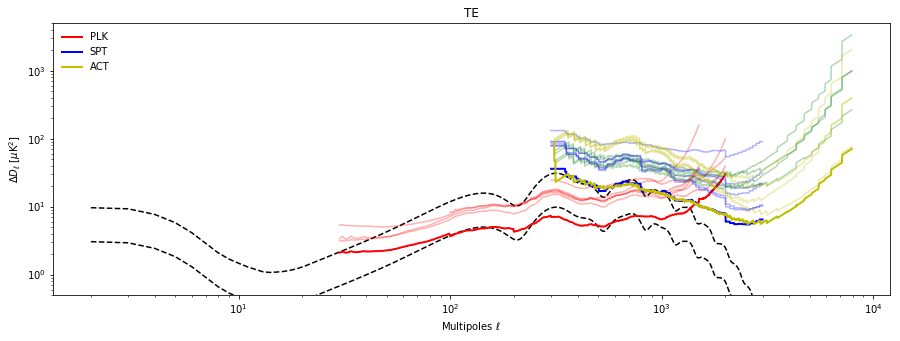

In [9]:
#TE
figure(figsize=(15,5))
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[3]**2+clth[0]*clth[1])/(2*lth+1))*1e12, 'k--')
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[3]**2+clth[0]*clth[1])/(2*lth+1)/0.1)*1e12, 'k--')
l = arange( 2001)
plot( l, sqrt(PLK['TE'].T), 'r', alpha=0.3)
plot( l, 1/sqrt(sum(1./PLK['TE'],0)), 'r', lw=2, label="PLK")
l = arange( 3201)
plot( l, sqrt(SPT['TE'].T), 'b', alpha=0.3)
plot( l, 1/sqrt(sum(1./SPT['TE'],0)), 'b', lw=2, label="SPT")
l = arange( 7924)
plot( l, (l*(l+1)/2/pi*sqrt(ACTw['TE'])).T, 'g', alpha=0.3)
plot( l, (l*(l+1)/2/pi*sqrt(ACTd['TE'])).T, 'y', alpha=0.3)
plot( l, l*(l+1)/2/pi/sqrt(sum(1./ACTw['TE']+1./ACTd['TE'],0)), 'y', lw=2, label="ACT")
loglog()
legend()
title("TE")
xlabel( "Multipoles $\ell$")
ylabel( "$\Delta D_\ell$ [$\mu$K$^2$]")
ylim( 5e-1, 5e3)

(0.002, 5000.0)

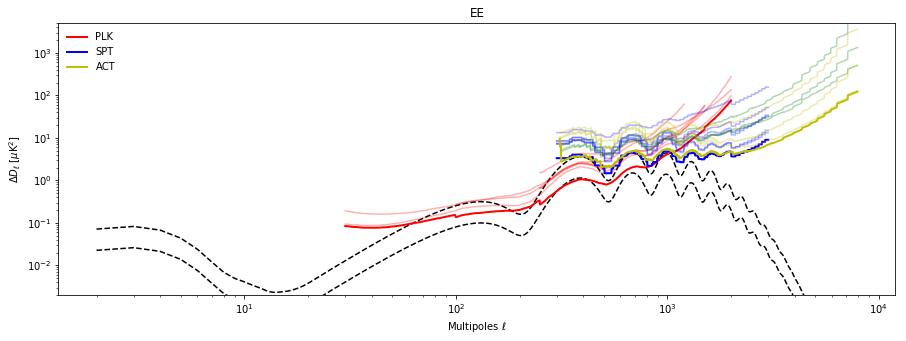

In [10]:
#EE
figure(figsize=(15,5))
#plot( lth, lth*(lth+1)/2/pi*clth[1]*1e12, 'k')
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[1]**2+clth[1]**2)/(2*lth+1))*1e12, 'k--')
plot( lth, lth*(lth+1)/2/pi*sqrt((clth[1]**2+clth[1]**2)/(2*lth+1)/0.1)*1e12, 'k--')
l = arange( 2001)
plot( l, sqrt(PLK['EE'].T), 'r', alpha=0.3)
plot( l, 1/sqrt(sum(1./PLK['EE'],0)), 'r', lw=2, label="PLK")
l = arange( 3201)
plot( l, sqrt(SPT['EE'].T), 'b', alpha=0.3)
plot( l, 1/sqrt(sum(1./SPT['EE'],0)), 'b', lw=2, label="SPT")
l = arange( 7924)
plot( l, (l*(l+1)/2/pi*sqrt(ACTw['EE'])).T, 'g', alpha=0.3)
plot( l, (l*(l+1)/2/pi*sqrt(ACTd['EE'])).T, 'y', alpha=0.3)
plot( l, l*(l+1)/2/pi/sqrt(sum(1./ACTw['EE']+1./ACTd['EE'],0)), 'y', lw=2, label="ACT")
loglog()
legend()
title("EE")
xlabel( "Multipoles $\ell$")
ylabel( "$\Delta D_\ell$ [$\mu$K$^2$]")
ylim( 2e-3, 5e3)